In [1]:
import json

# Read JSONL file
data = []
with open('raw_data.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(json.loads(line))

# Write as pretty JSON
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

print(f'Successfully converted {len(data)} records from raw_data.jsonl to data.json')


Successfully converted 100 records from raw_data.jsonl to data.json


In [2]:
# Load data and basic info
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Total records: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())
print(f"\nSource distribution:")
print(df['source'].value_counts())


Total records: 100

Columns: ['id', 'question', 'ground_truth', 'category', 'context', 'source']

Category distribution:
category
easy    50
hard    50
Name: count, dtype: int64

Source distribution:
source
European_Union_law                                                                                                                                                                                                                                                                                                                               19
Super_Bowl_50                                                                                                                                                                                                                                                                                                                                     5
Yuan_dynasty                                                                                                     

In [3]:
# Statistics by STRING LENGTH (characters)
df['context_len_chars'] = df['context'].apply(len)
df['question_len_chars'] = df['question'].apply(len)
df['ground_truth_len_chars'] = df['ground_truth'].apply(len)

print("=" * 60)
print("CONTEXT LENGTH STATISTICS (Characters)")
print("=" * 60)
print(df['context_len_chars'].describe())
print(f"\nMin: {df['context_len_chars'].min()}")
print(f"Max: {df['context_len_chars'].max()}")
print(f"Median: {df['context_len_chars'].median()}")
print(f"Mean: {df['context_len_chars'].mean():.2f}")
print(f"Std: {df['context_len_chars'].std():.2f}")

print("\n" + "=" * 60)
print("QUESTION LENGTH STATISTICS (Characters)")
print("=" * 60)
print(df['question_len_chars'].describe())

print("\n" + "=" * 60)
print("GROUND TRUTH LENGTH STATISTICS (Characters)")
print("=" * 60)
print(df['ground_truth_len_chars'].describe())


CONTEXT LENGTH STATISTICS (Characters)
count      100.0000
mean      3853.4200
std       2088.3934
min       1510.0000
25%       1979.2500
50%       3672.0000
75%       5354.7500
max      10454.0000
Name: context_len_chars, dtype: float64

Min: 1510
Max: 10454
Median: 3672.0
Mean: 3853.42
Std: 2088.39

QUESTION LENGTH STATISTICS (Characters)
count    100.000000
mean      77.360000
std       29.969183
min       32.000000
25%       58.000000
50%       69.500000
75%       93.250000
max      191.000000
Name: question_len_chars, dtype: float64

GROUND TRUTH LENGTH STATISTICS (Characters)
count    100.000000
mean      20.570000
std       20.922297
min        2.000000
25%        9.500000
50%       16.000000
75%       22.000000
max      140.000000
Name: ground_truth_len_chars, dtype: float64


In [5]:
!pip install tiktoken

   ---------------------------------------- 0.0/921.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.1 kB ? eta -:--:--
   ---------------------------------------- 921.1/921.1 kB 4.5 MB/s  0:00:00


In [6]:
# Statistics by TOKEN COUNT (using tiktoken for accurate token counting)
# Install: pip install tiktoken
import tiktoken

# Use cl100k_base encoding (GPT-4, GPT-3.5-turbo)
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(enc.encode(text))

df['context_len_tokens'] = df['context'].apply(count_tokens)
df['question_len_tokens'] = df['question'].apply(count_tokens)
df['ground_truth_len_tokens'] = df['ground_truth'].apply(count_tokens)

print("=" * 60)
print("CONTEXT LENGTH STATISTICS (Tokens - cl100k_base)")
print("=" * 60)
print(df['context_len_tokens'].describe())
print(f"\nMin: {df['context_len_tokens'].min()}")
print(f"Max: {df['context_len_tokens'].max()}")
print(f"Median: {df['context_len_tokens'].median()}")
print(f"Mean: {df['context_len_tokens'].mean():.2f}")
print(f"Std: {df['context_len_tokens'].std():.2f}")
print(f"Total tokens (all contexts): {df['context_len_tokens'].sum()}")

print("\n" + "=" * 60)
print("QUESTION LENGTH STATISTICS (Tokens)")
print("=" * 60)
print(df['question_len_tokens'].describe())

print("\n" + "=" * 60)
print("GROUND TRUTH LENGTH STATISTICS (Tokens)")
print("=" * 60)
print(df['ground_truth_len_tokens'].describe())


CONTEXT LENGTH STATISTICS (Tokens - cl100k_base)
count     100.00000
mean      846.77000
std       493.74755
min       280.00000
25%       396.25000
50%       781.00000
75%      1242.25000
max      2290.00000
Name: context_len_tokens, dtype: float64

Min: 280
Max: 2290
Median: 781.0
Mean: 846.77
Std: 493.75
Total tokens (all contexts): 84677

QUESTION LENGTH STATISTICS (Tokens)
count    100.000000
mean      16.390000
std        6.370537
min        6.000000
25%       12.000000
50%       15.000000
75%       18.250000
max       48.000000
Name: question_len_tokens, dtype: float64

GROUND TRUTH LENGTH STATISTICS (Tokens)
count    100.000000
mean       4.630000
std        4.272664
min        1.000000
25%        2.000000
50%        3.500000
75%        5.250000
max       28.000000
Name: ground_truth_len_tokens, dtype: float64


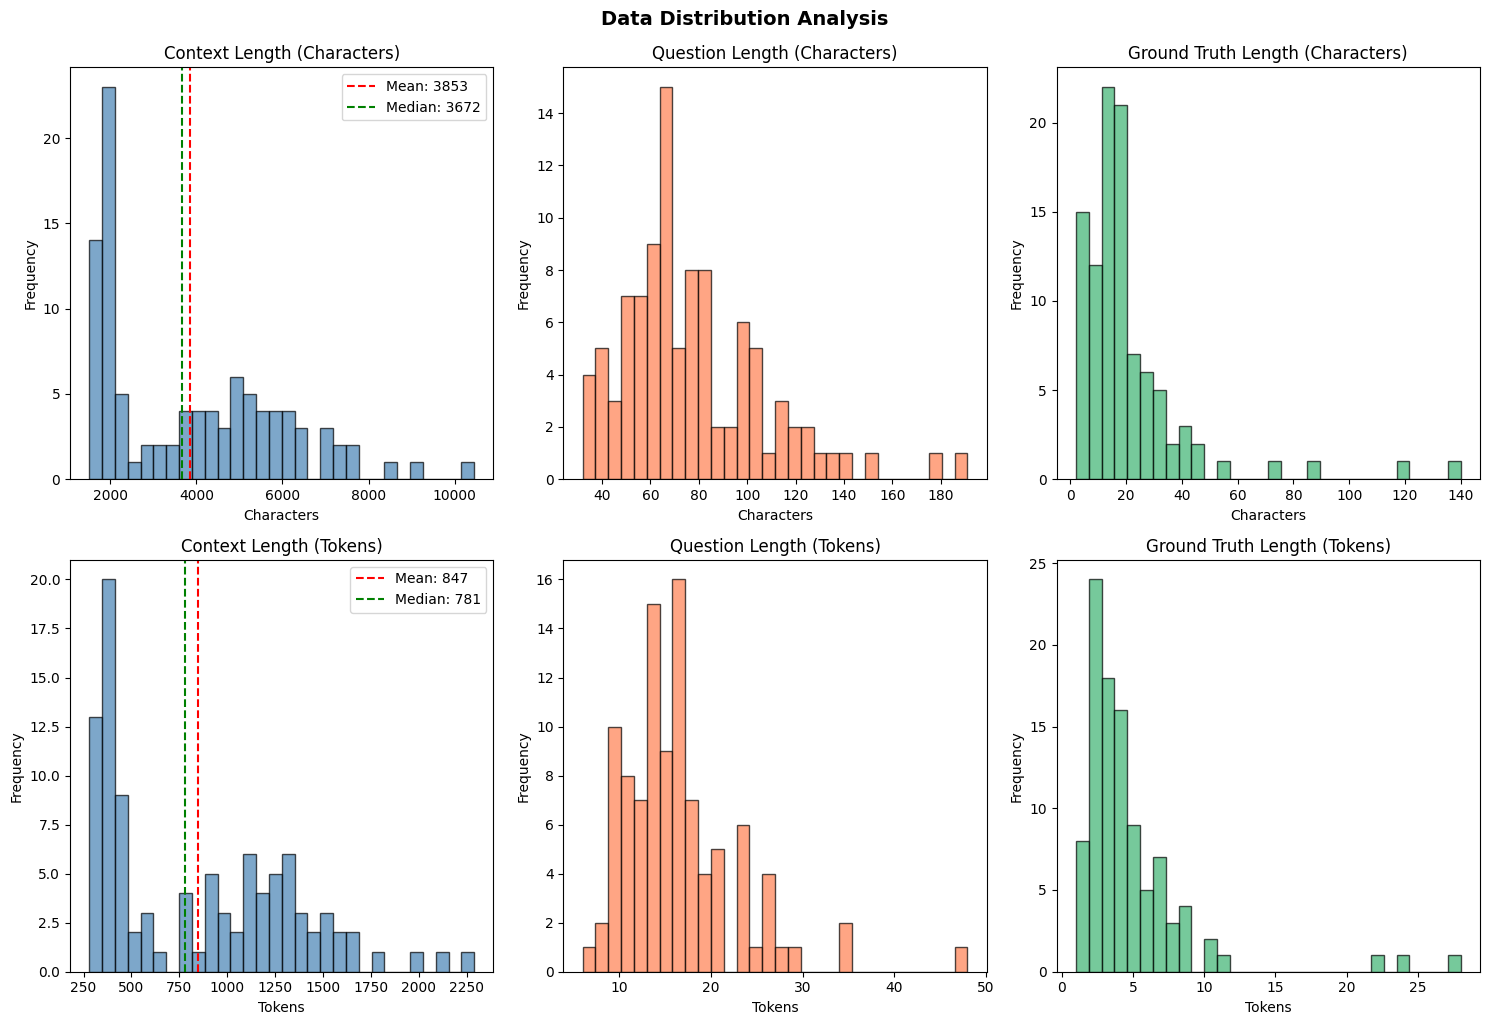

In [7]:
# Visualization - Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Character length distributions
axes[0, 0].hist(df['context_len_chars'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Context Length (Characters)')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['context_len_chars'].mean(), color='red', linestyle='--', label=f'Mean: {df["context_len_chars"].mean():.0f}')
axes[0, 0].axvline(df['context_len_chars'].median(), color='green', linestyle='--', label=f'Median: {df["context_len_chars"].median():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(df['question_len_chars'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Question Length (Characters)')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(df['ground_truth_len_chars'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0, 2].set_title('Ground Truth Length (Characters)')
axes[0, 2].set_xlabel('Characters')
axes[0, 2].set_ylabel('Frequency')

# Row 2: Token length distributions
axes[1, 0].hist(df['context_len_tokens'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_title('Context Length (Tokens)')
axes[1, 0].set_xlabel('Tokens')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['context_len_tokens'].mean(), color='red', linestyle='--', label=f'Mean: {df["context_len_tokens"].mean():.0f}')
axes[1, 0].axvline(df['context_len_tokens'].median(), color='green', linestyle='--', label=f'Median: {df["context_len_tokens"].median():.0f}')
axes[1, 0].legend()

axes[1, 1].hist(df['question_len_tokens'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title('Question Length (Tokens)')
axes[1, 1].set_xlabel('Tokens')
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].hist(df['ground_truth_len_tokens'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 2].set_title('Ground Truth Length (Tokens)')
axes[1, 2].set_xlabel('Tokens')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Data Distribution Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()


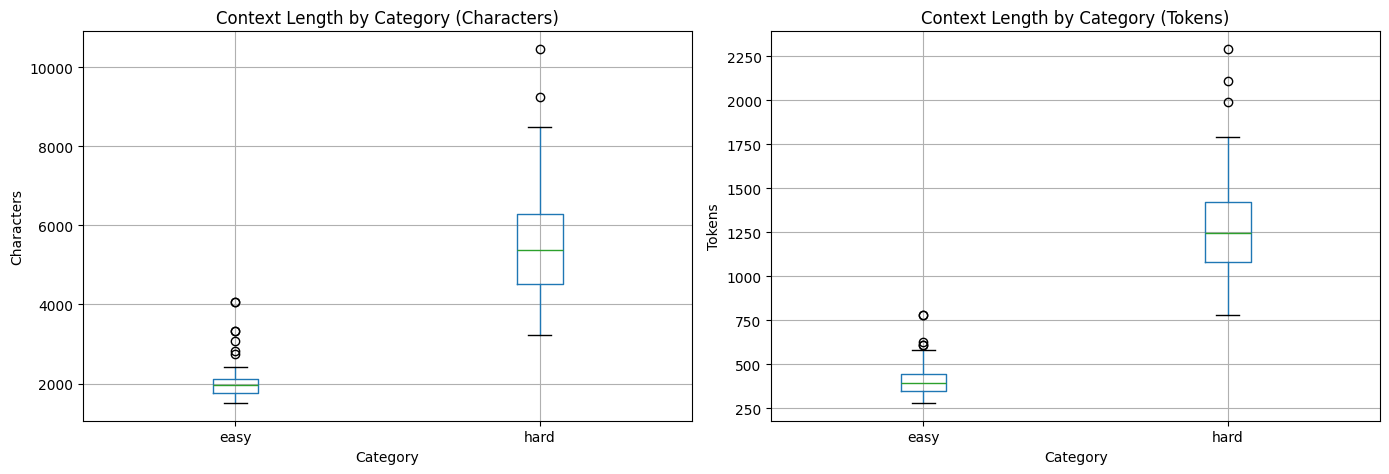

CONTEXT LENGTH BY CATEGORY

--- Characters ---
          count     mean          std     min      25%     50%      75%  \
category                                                                  
easy       50.0  2094.22   586.604699  1510.0  1752.75  1966.5  2121.75   
hard       50.0  5612.62  1466.898017  3230.0  4527.25  5377.5  6285.75   

              max  
category           
easy       4063.0  
hard      10454.0  

--- Tokens ---
          count     mean         std    min      25%     50%      75%     max
category                                                                     
easy       50.0   416.56  110.686754  280.0   345.75   394.5   443.00   781.0
hard       50.0  1276.98  320.283260  781.0  1080.00  1244.5  1424.25  2290.0


In [8]:
# Box plots by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Context length by category (Characters)
df.boxplot(column='context_len_chars', by='category', ax=axes[0])
axes[0].set_title('Context Length by Category (Characters)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Characters')

# Context length by category (Tokens)
df.boxplot(column='context_len_tokens', by='category', ax=axes[1])
axes[1].set_title('Context Length by Category (Tokens)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Tokens')

plt.suptitle('')  # Remove auto title
plt.tight_layout()
plt.show()

# Summary statistics by category
print("=" * 60)
print("CONTEXT LENGTH BY CATEGORY")
print("=" * 60)
print("\n--- Characters ---")
print(df.groupby('category')['context_len_chars'].describe())
print("\n--- Tokens ---")
print(df.groupby('category')['context_len_tokens'].describe())


In [9]:
# Summary Table - All fields comparison
summary_data = {
    'Field': ['context', 'question', 'ground_truth'],
    'Mean (chars)': [
        df['context_len_chars'].mean(),
        df['question_len_chars'].mean(),
        df['ground_truth_len_chars'].mean()
    ],
    'Median (chars)': [
        df['context_len_chars'].median(),
        df['question_len_chars'].median(),
        df['ground_truth_len_chars'].median()
    ],
    'Std (chars)': [
        df['context_len_chars'].std(),
        df['question_len_chars'].std(),
        df['ground_truth_len_chars'].std()
    ],
    'Mean (tokens)': [
        df['context_len_tokens'].mean(),
        df['question_len_tokens'].mean(),
        df['ground_truth_len_tokens'].mean()
    ],
    'Median (tokens)': [
        df['context_len_tokens'].median(),
        df['question_len_tokens'].median(),
        df['ground_truth_len_tokens'].median()
    ],
    'Std (tokens)': [
        df['context_len_tokens'].std(),
        df['question_len_tokens'].std(),
        df['ground_truth_len_tokens'].std()
    ],
}

summary_df = pd.DataFrame(summary_data)
print("=" * 80)
print("SUMMARY TABLE - All Fields")
print("=" * 80)
print(summary_df.to_string(index=False))

# Char to Token ratio
print("\n" + "=" * 80)
print("CHARACTER TO TOKEN RATIO")
print("=" * 80)
print(f"Context: {df['context_len_chars'].mean() / df['context_len_tokens'].mean():.2f} chars/token")
print(f"Question: {df['question_len_chars'].mean() / df['question_len_tokens'].mean():.2f} chars/token")
print(f"Ground Truth: {df['ground_truth_len_chars'].mean() / df['ground_truth_len_tokens'].mean():.2f} chars/token")


SUMMARY TABLE - All Fields
       Field  Mean (chars)  Median (chars)  Std (chars)  Mean (tokens)  Median (tokens)  Std (tokens)
     context       3853.42          3672.0  2088.393400         846.77            781.0    493.747550
    question         77.36            69.5    29.969183          16.39             15.0      6.370537
ground_truth         20.57            16.0    20.922297           4.63              3.5      4.272664

CHARACTER TO TOKEN RATIO
Context: 4.55 chars/token
Question: 4.72 chars/token
Ground Truth: 4.44 chars/token


In [1]:
def entropy_to_k(entropy, k_min=0, k_max=10, steepness=20, midpoint=0.4):
    """
    Map entropy [0, ~1] to k ∈ [k_min, k_max] using a sigmoid function.

    Parameters:
    - entropy: float, 0..1, đo độ không chắc chắn Phase 1 output
    - k_min: minimum documents
    - k_max: maximum documents
    - steepness: độ dốc sigmoid, càng cao càng nhạy
    - midpoint: entropy value tại midpoint sigmoid (nơi k ≈ (k_min+k_max)/2)

    Returns:
    - k: int, số document để retrieve
    """

    # Sigmoid function
    s = 1 / (1 + math.exp(-steepness * (entropy - midpoint)))

    # Map sigmoid [0,1] -> [k_min, k_max]
    k = k_min + s * (k_max - k_min)

    return int(round(k))

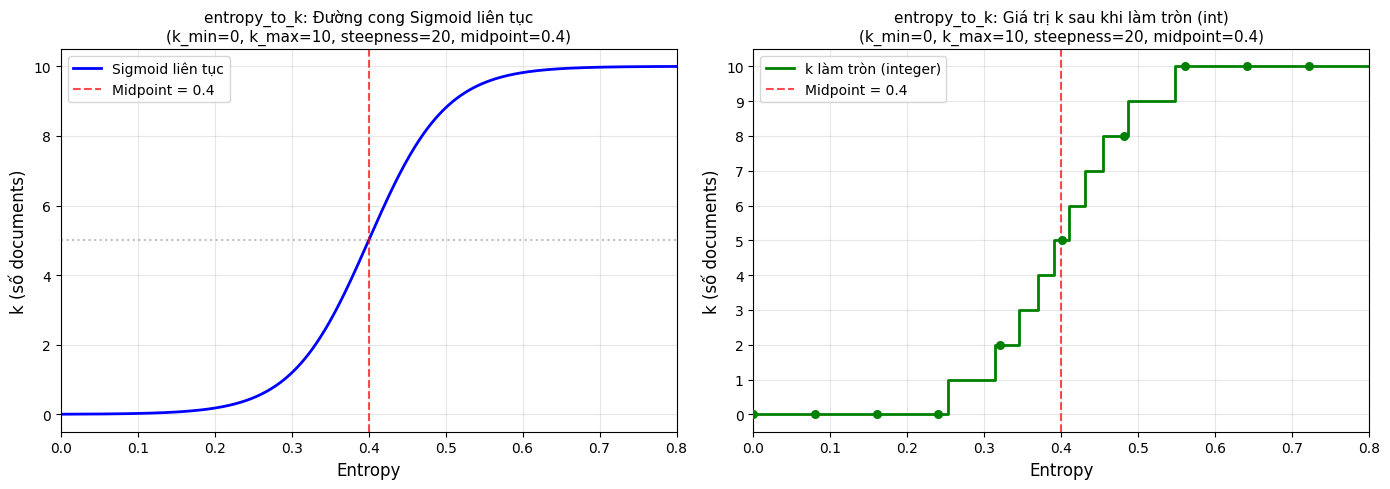


=== Bảng giá trị entropy -> k ===
Entropy    k (continuous)  k (rounded)
-----------------------------------
0.00       0.00            0         
0.05       0.01            0         
0.10       0.02            0         
0.15       0.07            0         
0.20       0.18            0         
0.25       0.47            0         
0.30       1.19            1         
0.35       2.69            3         
0.40       5.00            5         
0.45       7.31            7         
0.50       8.81            9         
0.55       9.53            10        
0.60       9.82            10        
0.65       9.93            10        
0.70       9.98            10        
0.75       9.99            10        
0.80       10.00           10        


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

def entropy_to_k(entropy, k_min=0, k_max=10, steepness=20, midpoint=0.4):
    """Map entropy [0, ~1] to k ∈ [k_min, k_max] using a sigmoid function."""
    s = 1 / (1 + math.exp(-steepness * (entropy - midpoint)))
    k = k_min + s * (k_max - k_min)
    return int(round(k))

def entropy_to_k_continuous(entropy, k_min=0, k_max=10, steepness=20, midpoint=0.4):
    """Version không làm tròn để vẽ đường cong mượt hơn."""
    s = 1 / (1 + np.exp(-steepness * (entropy - midpoint)))
    k = k_min + s * (k_max - k_min)
    return k

# Tạo dữ liệu
entropy_values = np.linspace(0.0, 0.8, 500)
k_continuous = entropy_to_k_continuous(entropy_values)
k_discrete = [entropy_to_k(e) for e in entropy_values]

# Tạo figure với 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Đường cong sigmoid liên tục
ax1 = axes[0]
ax1.plot(entropy_values, k_continuous, 'b-', linewidth=2, label='Sigmoid liên tục')
ax1.axvline(x=0.4, color='r', linestyle='--', alpha=0.7, label=f'Midpoint = 0.4')
ax1.axhline(y=5, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Entropy', fontsize=12)
ax1.set_ylabel('k (số documents)', fontsize=12)
ax1.set_title('entropy_to_k: Đường cong Sigmoid liên tục\n(k_min=0, k_max=10, steepness=20, midpoint=0.4)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 0.8)
ax1.set_ylim(-0.5, 10.5)

# Plot 2: Giá trị k sau khi làm tròn (discrete)
ax2 = axes[1]
ax2.step(entropy_values, k_discrete, 'g-', linewidth=2, where='mid', label='k làm tròn (integer)')
ax2.scatter(entropy_values[::50], [entropy_to_k(e) for e in entropy_values[::50]], 
            color='green', s=30, zorder=5)
ax2.axvline(x=0.4, color='r', linestyle='--', alpha=0.7, label=f'Midpoint = 0.4')
ax2.set_xlabel('Entropy', fontsize=12)
ax2.set_ylabel('k (số documents)', fontsize=12)
ax2.set_title('entropy_to_k: Giá trị k sau khi làm tròn (int)\n(k_min=0, k_max=10, steepness=20, midpoint=0.4)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 0.8)
ax2.set_ylim(-0.5, 10.5)
ax2.set_yticks(range(0, 11))

plt.tight_layout()
plt.show()

# In bảng giá trị tham khảo
print("\n=== Bảng giá trị entropy -> k ===")
print(f"{'Entropy':<10} {'k (continuous)':<15} {'k (rounded)':<10}")
print("-" * 35)
for e in np.arange(0.0, 0.85, 0.05):
    k_cont = entropy_to_k_continuous(e)
    k_int = entropy_to_k(e)
    print(f"{e:<10.2f} {k_cont:<15.2f} {k_int:<10}")